In [6]:
import math
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
import saws
import warms

/work/dlclarge1/mallik-warmstarting/envs/nyoy_env/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
from warms.post_hoc_analysis import recurse_collect_run_paths

In [72]:
PARAM_MAP = param_map = {
    "s1": 14562560,
    "s2": 32270848,
    "s3": 77124608,
    "s4": 134561280,
    "s5": 287183360,
    "s6": 610488320,
    "s7": 1217722368,
}


WIDTH_MAP = width_map = {
    "s0": 64,
    "s1": 128,
    "s2": 256,
    "s3": 512,
    "s4": 768,
    "s5": 1280,
    "s6": 2048,
    "s7": 3072,
}

In [79]:
# demo run

df = pd.read_parquet(
    # Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/shrinking_laws/s1-s3/10tkpm/shrinking=0.2/seed=666/post_hoc_analysis.parquet")
    Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/neurips/n_heads/mup_scaled_batch/s2-s3/seed=666/post_hoc_analysis.parquet")
)
# display(df.head)
print(df.columns)

Index(['l1_norm', 'l2_norm', 'rms_norm', 'effective_rank', 'op_norm_rms_inf',
       'cosine_to_prev', 'radial', 'angular_norm', 'dW_norm',
       'radial_fraction', 'angular_fraction'],
      dtype='object')


<Figure size 640x480 with 0 Axes>

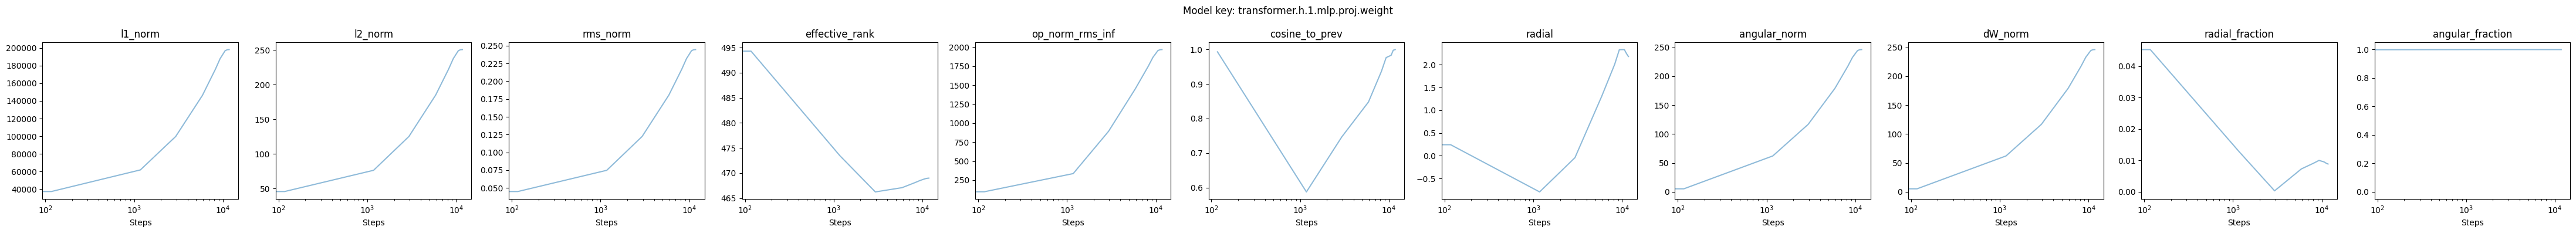

In [80]:
plt.clf()

cols = df.columns
fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 4))

# for _key in df.index.get_level_values(0).unique():
while _key := np.random.choice(df.index.get_level_values(0).unique()):
    if "norm" in _key or "bias" in _key:
        continue
    for i, col in enumerate(cols):
        __df = df.loc[_key, col]
        axes[i].plot(__df.index, __df.values, alpha=0.5)
        axes[i].set_title(col)
    break

for i, col in enumerate(cols):
    axes[i].set_xscale("log")
    axes[i].set_xlabel("Steps")
plt.suptitle(f"Model key: {_key}")
plt.tight_layout()
plt.show()

---

In [83]:
# Loading via flattened data frame

BASE_DATA_PATH = Path("/work/dlclarge1/mallik-warmstarting/misc/neeratyoy/code/warmstarting_exps/playground/warmstart_runs_flattened.parquet")
full_df = pd.read_parquet(BASE_DATA_PATH)
display(full_df)

tag,tokens,flops,Train Loss,Validation Loss,tkpm,base_N,target_N,shrink,adam_beta_1,adam_beta_2,...,weight_decay,seed,mup,n_layer,n_embd,n_head,warmstart_type,method,shrinking,post_hoc_df
0,0,0.000000e+00,10.957504,10.984583,10.0,14562560,32270848,0.2,0.9,0.95,...,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2,/work/dlclarge1/mallik-warmstarting/warmstarti...
1,65536,1.268941e+13,11.012417,NaN,10.0,14562560,32270848,0.2,0.9,0.95,...,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2,/work/dlclarge1/mallik-warmstarting/warmstarti...
2,131072,2.537883e+13,10.583125,NaN,10.0,14562560,32270848,0.2,0.9,0.95,...,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2,/work/dlclarge1/mallik-warmstarting/warmstarti...
3,196608,3.806824e+13,9.702733,NaN,10.0,14562560,32270848,0.2,0.9,0.95,...,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2,/work/dlclarge1/mallik-warmstarting/warmstarti...
4,262144,5.075766e+13,8.710074,NaN,10.0,14562560,32270848,0.2,0.9,0.95,...,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2,/work/dlclarge1/mallik-warmstarting/warmstarti...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2467540,8612610048,1.484039e+19,1.648397,NaN,30.0,77124608,287183360,0.4,0.9,0.95,...,0,666,True,8,1280,20,net2net,net2net,NaN,/work/dlclarge1/mallik-warmstarting/warmstarti...
2467541,8613126144,1.484128e+19,1.625308,NaN,30.0,77124608,287183360,0.4,0.9,0.95,...,0,666,True,8,1280,20,net2net,net2net,NaN,/work/dlclarge1/mallik-warmstarting/warmstarti...
2467542,8613642240,1.484217e+19,1.566380,NaN,30.0,77124608,287183360,0.4,0.9,0.95,...,0,666,True,8,1280,20,net2net,net2net,NaN,/work/dlclarge1/mallik-warmstarting/warmstarti...
2467543,8614158336,1.484306e+19,1.630695,NaN,30.0,77124608,287183360,0.4,0.9,0.95,...,0,666,True,8,1280,20,net2net,net2net,NaN,/work/dlclarge1/mallik-warmstarting/warmstarti...


In [82]:
full_df.post_hoc_df.isna().sum()

0

In [ ]:
# adding g columns

base_width = lambda x: WIDTH_MAP[[k for k, v in PARAM_MAP.items() if v == x][0]]

full_df["g_width"] = full_df["n_embd"] / full_df["base_N"].apply(base_width)
full_df["g_N"] = full_df["target_N"] / full_df["base_N"]
sorted(full_df["g_width"].unique()), sorted(full_df["g_N"].unique())

([1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 16.0],
 [1.7447256263526163,
  2.216014766634438,
  2.389915753066049,
  3.7236281317630815,
  4.169747259198147,
  5.296088599806628,
  7.915610021641861,
  8.89915753066049,
  9.240221499516569,
  15.78902505410465,
  18.91764108584937,
  19.720664498549706,
  41.92177199613255])

In [86]:
def read_post_hoc_parquet(path: Path) -> pd.DataFrame:
    return pd.read_parquet(path)

In [194]:
PLOT_OUTPUT_PATH = Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/plots/post_hoc_analysis")

#### Hypo 1: FP does not fully utilize capacity of widened network (Rank Collapse)

Here, we compare Net2Net and SZP (and Scratch?) over steps for some of the weights:
* `transformer.wte.weight`
* `transformer.h.4.attn.attn.weight`
* `transformer.h.4.mlp.proj.weight`
* `lm_head.weight`

Metrics to test:
* `Effective Rank`
* `RMSNorm`
* `Operator Norm`
* `Cosine Similarity change`
  * wrt to t=0
  * wrt to t=t'-1

Things to observe:
* Difference in starting ranks 
* Rate of rank decrease
* Norm growth (connect with Lyle et al. plasticity)

In [197]:
baseline = "net2net"
BASELINE = "N2N"
BASELINE_COLOR = "blue"

ours = "snp_zeros_with_mup"
OURS = "SZP"
ours_shrinking = 0.4
OUR_COLOR = "orange"

Y_METRIC = "Validation Loss"
X_METRIC = "Flops"

baseline_df = full_df.loc[full_df.warmstart_type == baseline]
ours_df = full_df.loc[
    (full_df.warmstart_type == ours) & (full_df.shrink == ours_shrinking)
]

display(baseline_df.head())
display(ours_df.head())

tag,tokens,flops,Train Loss,Validation Loss,tkpm,base_N,target_N,shrink,adam_beta_1,adam_beta_2,...,mup,n_layer,n_embd,n_head,warmstart_type,method,shrinking,post_hoc_df,g_width,g_N
2205639,0,0.000000e+00,11.326118,11.361635,10.0,14562560,32270848,0.4,0.9,0.95,...,True,8,256,4,net2net,net2net,NaN,/work/dlclarge1/mallik-warmstarting/warmstarti...,2.0,2.216015
2205640,65536,1.268941e+13,11.374968,NaN,10.0,14562560,32270848,0.4,0.9,0.95,...,True,8,256,4,net2net,net2net,NaN,/work/dlclarge1/mallik-warmstarting/warmstarti...,2.0,2.216015
2205641,131072,2.537883e+13,10.877325,NaN,10.0,14562560,32270848,0.4,0.9,0.95,...,True,8,256,4,net2net,net2net,NaN,/work/dlclarge1/mallik-warmstarting/warmstarti...,2.0,2.216015
2205642,196608,3.806824e+13,9.590896,NaN,10.0,14562560,32270848,0.4,0.9,0.95,...,True,8,256,4,net2net,net2net,NaN,/work/dlclarge1/mallik-warmstarting/warmstarti...,2.0,2.216015
2205643,262144,5.075766e+13,8.118587,NaN,10.0,14562560,32270848,0.4,0.9,0.95,...,True,8,256,4,net2net,net2net,NaN,/work/dlclarge1/mallik-warmstarting/warmstarti...,2.0,2.216015


tag,tokens,flops,Train Loss,Validation Loss,tkpm,base_N,target_N,shrink,adam_beta_1,adam_beta_2,...,mup,n_layer,n_embd,n_head,warmstart_type,method,shrinking,post_hoc_df,g_width,g_N
4924,0,0.000000e+00,9.508313,9.486343,10.0,14562560,32270848,0.4,0.9,0.95,...,True,8,256,4,snp_zeros_with_mup,paws,0.4,/work/dlclarge1/mallik-warmstarting/warmstarti...,2.0,2.216015
4925,65536,1.268941e+13,9.478653,NaN,10.0,14562560,32270848,0.4,0.9,0.95,...,True,8,256,4,snp_zeros_with_mup,paws,0.4,/work/dlclarge1/mallik-warmstarting/warmstarti...,2.0,2.216015
4926,131072,2.537883e+13,8.954137,NaN,10.0,14562560,32270848,0.4,0.9,0.95,...,True,8,256,4,snp_zeros_with_mup,paws,0.4,/work/dlclarge1/mallik-warmstarting/warmstarti...,2.0,2.216015
4927,196608,3.806824e+13,7.887499,NaN,10.0,14562560,32270848,0.4,0.9,0.95,...,True,8,256,4,snp_zeros_with_mup,paws,0.4,/work/dlclarge1/mallik-warmstarting/warmstarti...,2.0,2.216015
4928,262144,5.075766e+13,6.921789,NaN,10.0,14562560,32270848,0.4,0.9,0.95,...,True,8,256,4,snp_zeros_with_mup,paws,0.4,/work/dlclarge1/mallik-warmstarting/warmstarti...,2.0,2.216015


In [131]:
read_post_hoc_parquet(baseline_df.post_hoc_df.values[10]).columns
# read_post_hoc_parquet(baseline_df.post_hoc_df.values[10]).index.get_level_values(0).unique()

Index(['l1_norm', 'l2_norm', 'rms_norm', 'effective_rank', 'op_norm_rms_inf',
       'cosine_to_prev', 'radial', 'angular_norm', 'dW_norm',
       'radial_fraction', 'angular_fraction'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

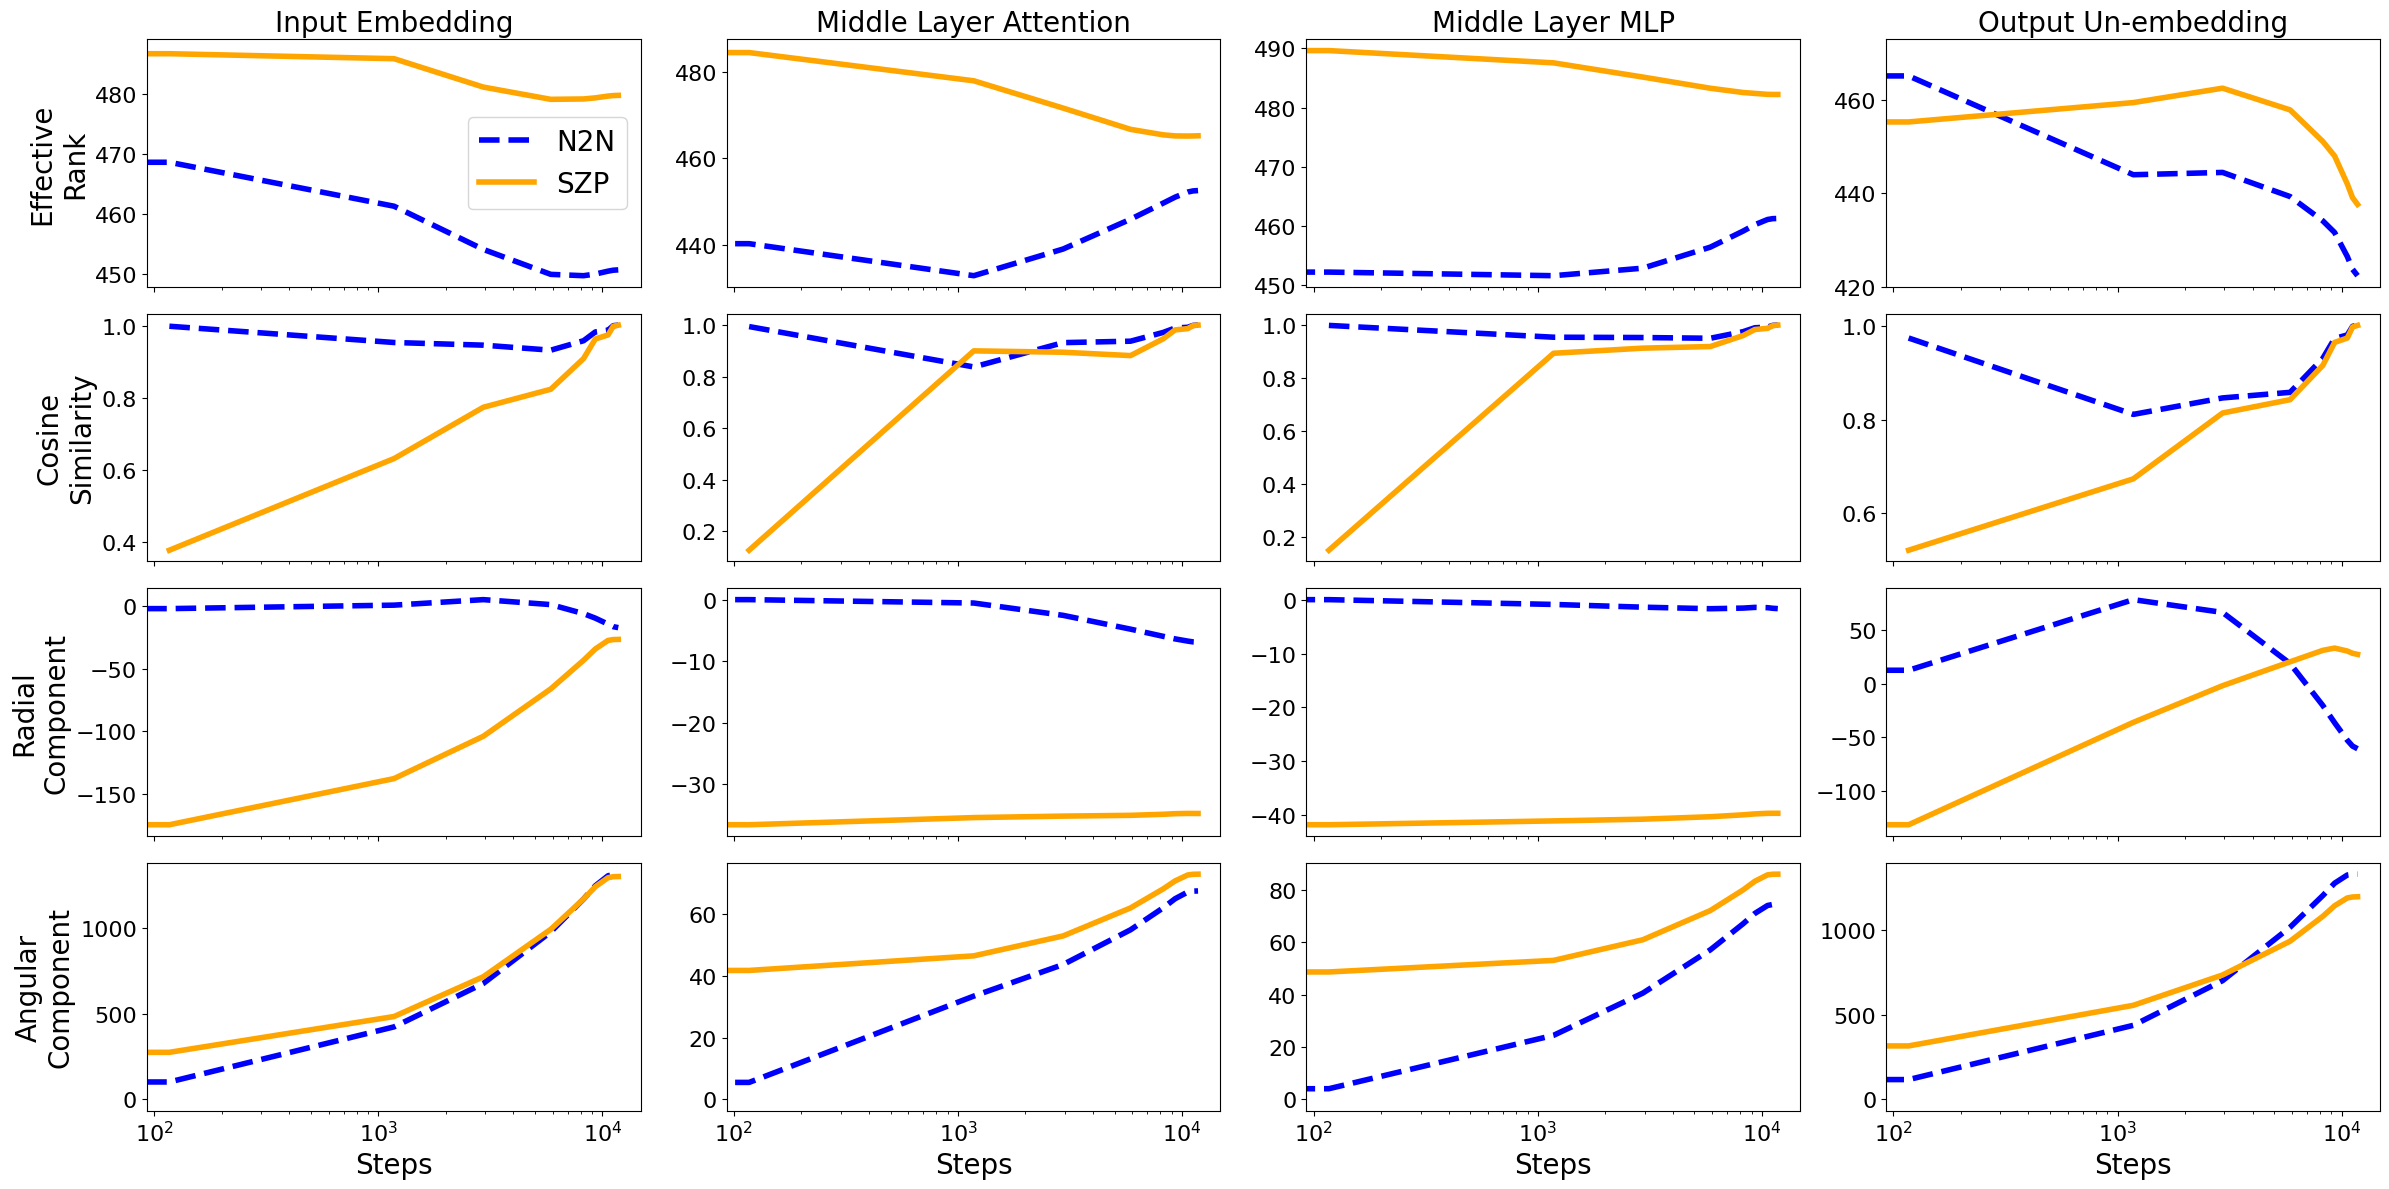

In [ ]:
# grouping based on smallest g and largest g

METRICS = [
    "effective_rank",
    # "op_norm_rms_inf",
    "cosine_to_prev",
    # "dW_norm",
    "radial",
    "angular_norm",
    # "radial_fraction",
    # "angular_fraction",
]
METRIC_NAMES = {
    "effective_rank": "Effective\nRank",
    "op_norm_rms_inf": "Operator Norm (RMS Inf)",
    "cosine_to_prev": "Cosine\nSimilarity",
    "dW_norm": "Norm of Weight Update",
    "radial": "Radial\nComponent",
    "angular_norm": "Angular\nComponent",
    "radial_fraction": "Radial\nFraction",
    "angular_fraction": "Angular\nFraction",
}
Y_LOG_BOOLS = {  # 1-to-1 with METRICS
    "effective_rank": False,
    "op_norm_rms_inf": True,
    "cosine_to_prev": False,
    "dW_norm": False,
    "radial": False,
    "angular_norm": False,
    "radial_fraction": False,
    "angular_fraction": True,
}

LAYERS = [
    "transformer.wte.weight",
    "transformer.h.4.attn.attn.weight",
    "transformer.h.4.mlp.fc.weight",
    "lm_head.weight",
]
LAYER_MAP = {
    "transformer.wte.weight": "Input Embedding",
    "transformer.h.4.attn.attn.weight": "Middle Layer Attention",
    "transformer.h.4.mlp.fc.weight": "Middle Layer MLP",
    "lm_head.weight": "Output Un-embedding",
}

TKPMS = 20.0

G_CHOICE = "g_width"

_gs = sorted(set(baseline_df[G_CHOICE].unique()).intersection(ours_df[G_CHOICE].unique()))
g_min = min(_gs)
g_max = max(_gs)
_g_opt = [min(np.abs(v - 4), np.abs(v - 5)) for v in _gs]
g_opt = _gs[np.argmin(_g_opt)]

G_LIM_CHOICE = g_opt

# subsetting dfs by g and tkpm
_baseline_df = baseline_df.loc[(baseline_df[G_CHOICE] == G_LIM_CHOICE) & (baseline_df["tkpm"] == TKPMS)]
_ours_df = ours_df.loc[(ours_df[G_CHOICE] == G_LIM_CHOICE) & (ours_df["tkpm"] == TKPMS)]

# keeping the largest target_N for each algo
_baseline_df = _baseline_df.sort_values("target_N", ascending=True).drop_duplicates("target_N", keep="last")
_ours_df = _ours_df.sort_values("target_N", ascending=True).drop_duplicates("target_N", keep="last")

_baseline_metric_df = read_post_hoc_parquet(_baseline_df.post_hoc_df.values[0])
_ours_metric_df = read_post_hoc_parquet(_ours_df.post_hoc_df.values[0])

plt.clf()
# metrics along rows, layers along columns
fig, axes = plt.subplots(len(METRICS), len(LAYERS), figsize=(6 * len(LAYERS), 3 * len(METRICS)), sharex=True)

# plotting for g_min only
for i, metric in enumerate(METRICS):
    for j, layer in enumerate(LAYERS):
        axes[i, j].plot(
            _baseline_metric_df.xs(layer)[metric].index,
            _baseline_metric_df.xs(layer)[metric].values,
            label=BASELINE,
            linewidth=4,
            linestyle="--",
            color=BASELINE_COLOR,
        )
        axes[i, j].plot(
            _ours_metric_df.xs(layer)[metric].index,
            _ours_metric_df.xs(layer)[metric].values,
            label=OURS,
            linewidth=4,
            color=OUR_COLOR,
        )
        if Y_LOG_BOOLS[metric]:
            axes[i, j].set_yscale("log")
        if i == len(METRICS) - 1:
            axes[i, j].set_xlabel("Steps", fontsize=20)
        if i == 0:
            axes[i, j].set_title(f"{LAYER_MAP[layer]}", fontsize=20)
        if j == 0:
            axes[i, j].set_ylabel(METRIC_NAMES[metric], fontsize=20)
        if i == 0 and j == 0:
            axes[i, j].legend(fontsize=20)
        axes[i, j].set_xscale("log")
        axes[i, j].tick_params(axis="both", which="major", labelsize=16)
# plt.suptitle(f"{G_CHOICE} = {G_LIM_CHOICE}", fontsize=24)
plt.suptitle(f"g={G_LIM_CHOICE}", fontsize=24)  # NOTE: comment this out when saving finally for paper
plt.tight_layout()
plt.savefig(PLOT_OUTPUT_PATH / f"post_hoc_{G_CHOICE}={G_LIM_CHOICE}.pdf", dpi=150, bbox_inches="tight")
plt.show()

#### Hypo 2: Role of shrinking in signal propagation

Here, we compare shrinking=1.0 and shrinking=0.4 over steps for some of the weights:
* `transformer.wte.weight`
* `transformer.h.4.attn.attn.weight`
* `transformer.h.4.mlp.proj.weight`
* `lm_head.weight`

Metrics to test:
* `Effective Rank`
* `RMSNorm`
* `Operator Norm`

Things to observe:
* Norm differences 
* Norm growth (connect with Lyle et al. plasticity)
* Cosine Similarity differences

<Figure size 640x480 with 0 Axes>

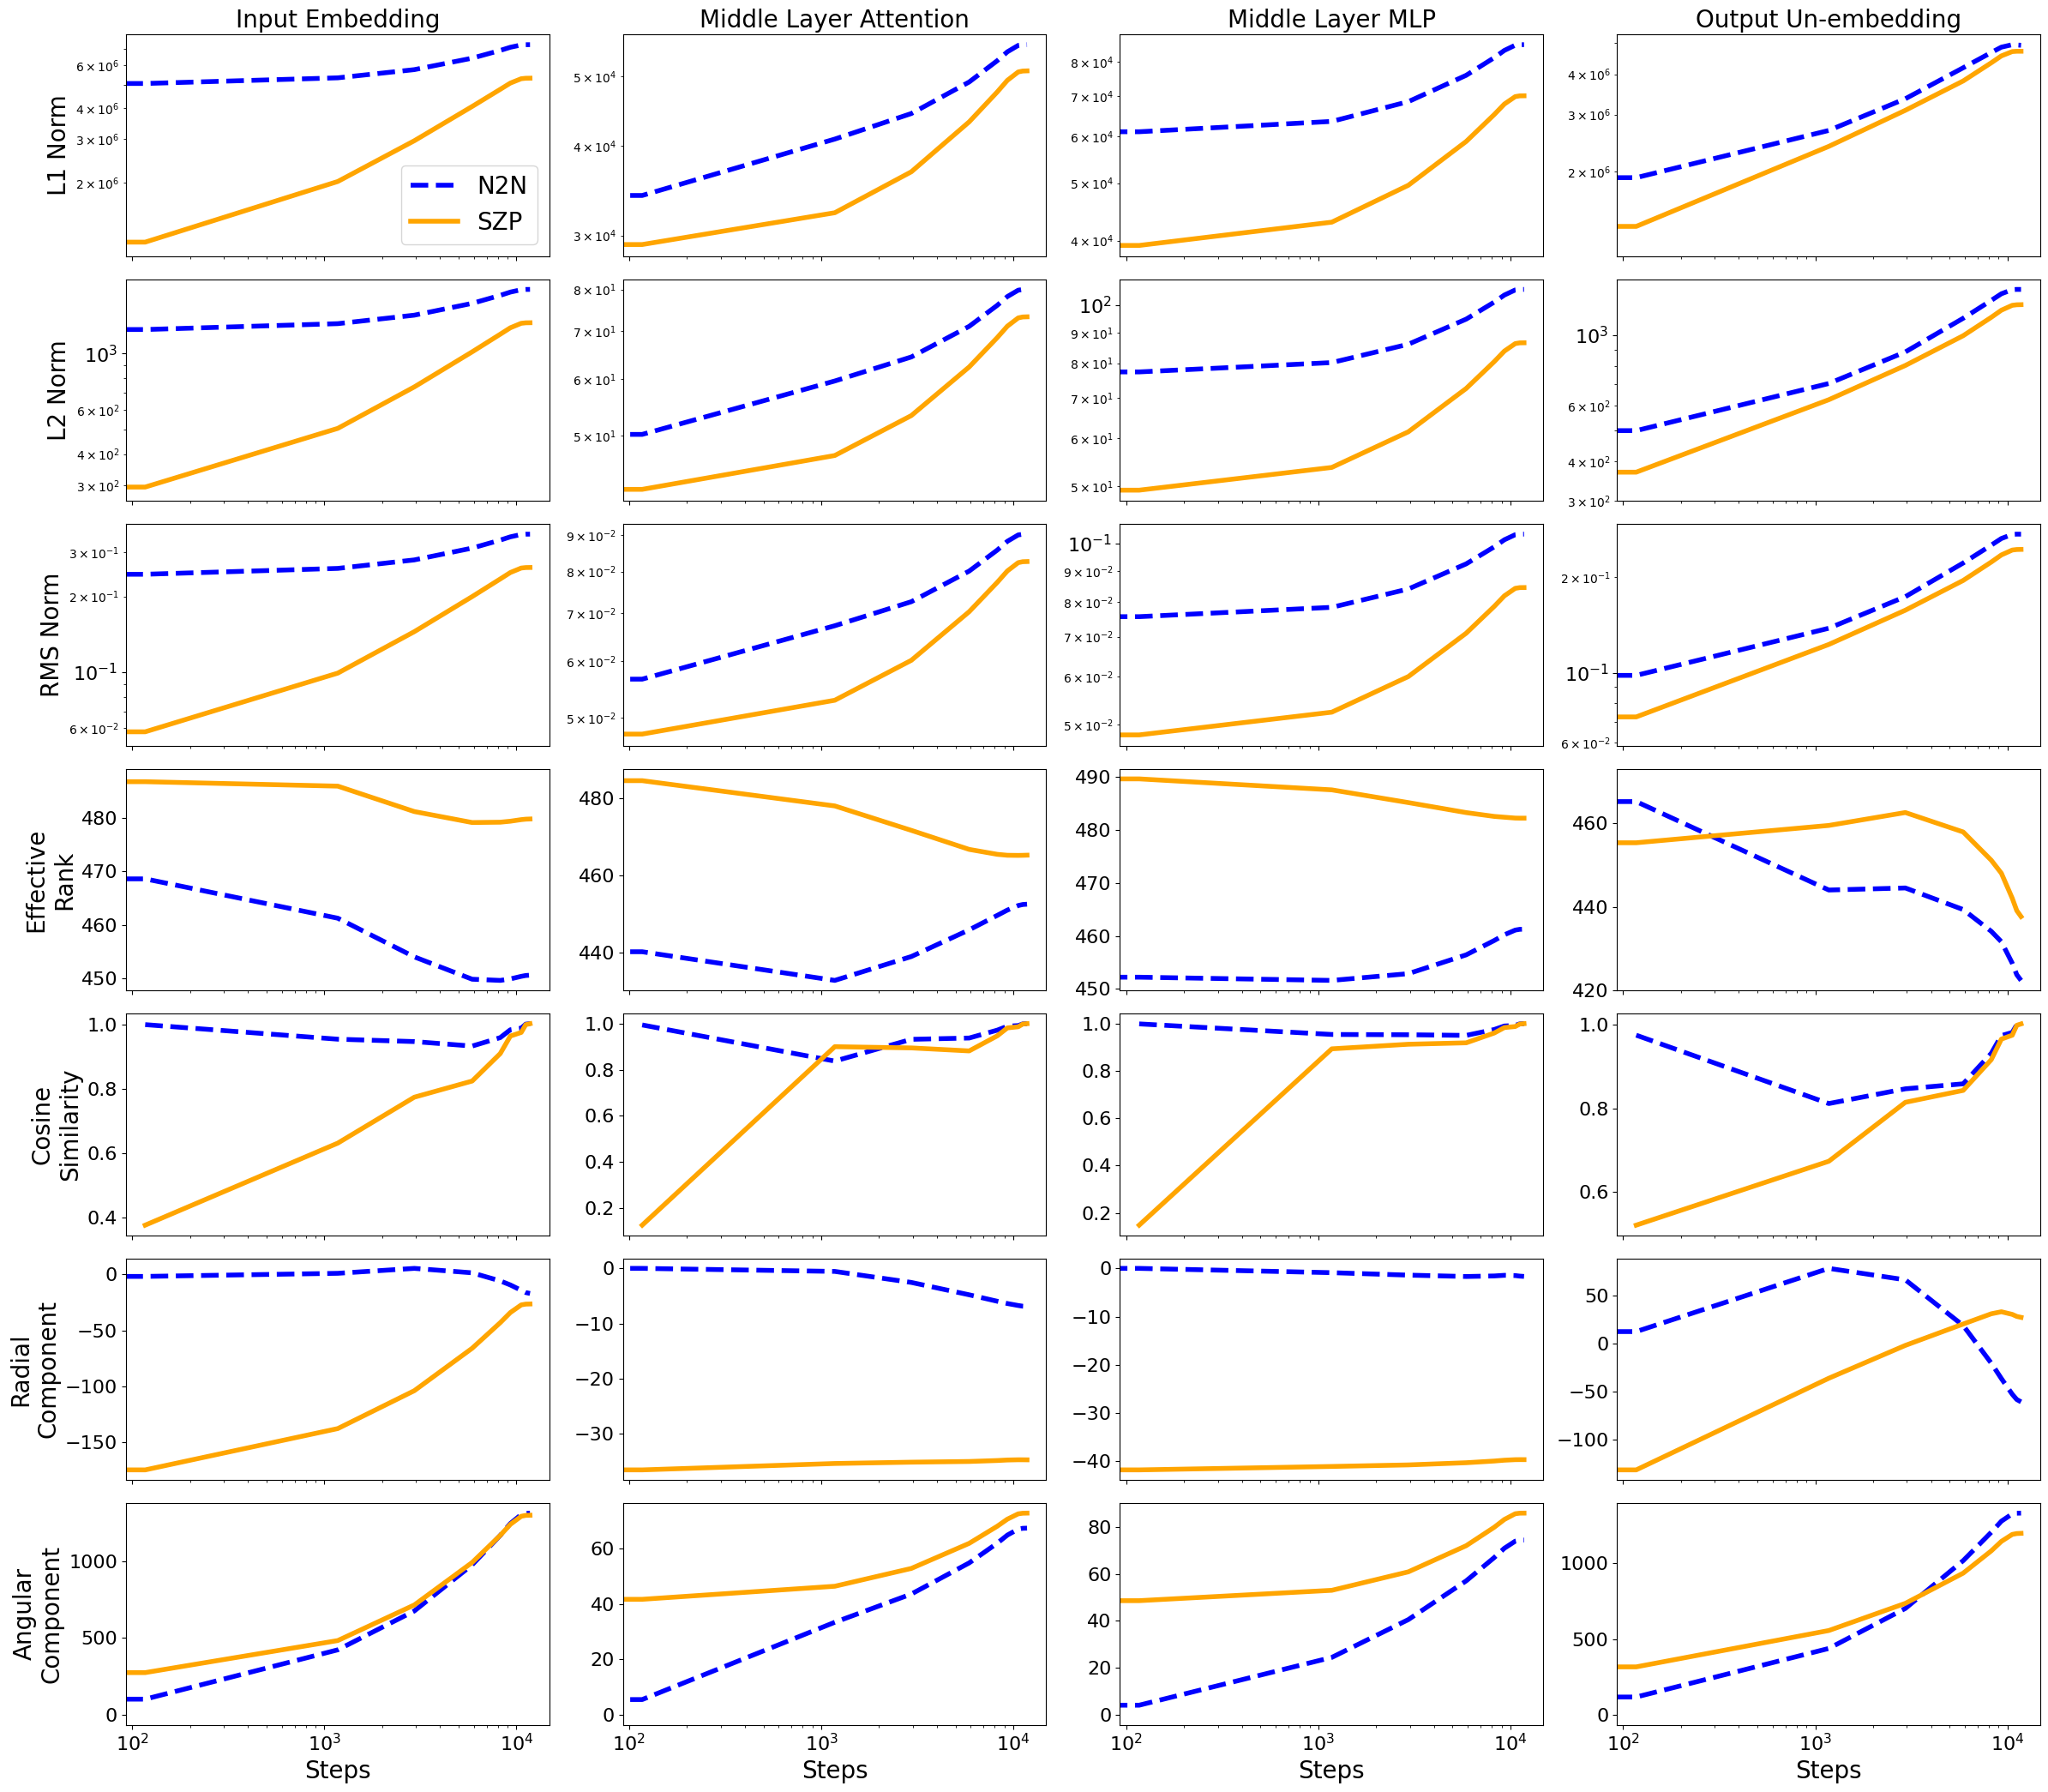

In [199]:
# grouping based on smallest g and largest g

METRICS = [
    "l1_norm",
    "l2_norm",
    "rms_norm",
    "effective_rank",
    # "op_norm_rms_inf",
    "cosine_to_prev",
    # "dW_norm",
    "radial",
    "angular_norm",
    # "radial_fraction",
    # "angular_fraction",
]
METRIC_NAMES = {
    "l1_norm": "L1 Norm",
    "l2_norm": "L2 Norm",
    "rms_norm": "RMS Norm",
    "effective_rank": "Effective\nRank",
    "op_norm_rms_inf": "Operator Norm (RMS Inf)",
    "cosine_to_prev": "Cosine\nSimilarity",
    "dW_norm": "Norm of Weight Update",
    "radial": "Radial\nComponent",
    "angular_norm": "Angular\nComponent",
    "radial_fraction": "Radial\nFraction",
    "angular_fraction": "Angular\nFraction",
}
Y_LOG_BOOLS = {  # 1-to-1 with METRICS
    "l1_norm": True,
    "l2_norm": True,
    "rms_norm": True,
    "effective_rank": False,
    "op_norm_rms_inf": True,
    "cosine_to_prev": False,
    "dW_norm": False,
    "radial": False,
    "angular_norm": False,
    "radial_fraction": False,
    "angular_fraction": True,
}

LAYERS = [
    "transformer.wte.weight",
    "transformer.h.4.attn.attn.weight",
    "transformer.h.4.mlp.fc.weight",
    "lm_head.weight",
]
LAYER_MAP = {
    "transformer.wte.weight": "Input Embedding",
    "transformer.h.4.attn.attn.weight": "Middle Layer Attention",
    "transformer.h.4.mlp.fc.weight": "Middle Layer MLP",
    "lm_head.weight": "Output Un-embedding",
}

TKPMS = 20.0

G_CHOICE = "g_width"

_gs = sorted(set(baseline_df[G_CHOICE].unique()).intersection(ours_df[G_CHOICE].unique()))
g_min = min(_gs)
g_max = max(_gs)
_g_opt = [min(np.abs(v - 4), np.abs(v - 5)) for v in _gs]
g_opt = _gs[np.argmin(_g_opt)]

G_LIM_CHOICE = g_opt

# subsetting dfs by g and tkpm
_baseline_df = baseline_df.loc[(baseline_df[G_CHOICE] == G_LIM_CHOICE) & (baseline_df["tkpm"] == TKPMS)]
_ours_df = ours_df.loc[(ours_df[G_CHOICE] == G_LIM_CHOICE) & (ours_df["tkpm"] == TKPMS)]

# keeping the largest target_N for each algo
_baseline_df = _baseline_df.sort_values("target_N", ascending=True).drop_duplicates("target_N", keep="last")
_ours_df = _ours_df.sort_values("target_N", ascending=True).drop_duplicates("target_N", keep="last")

_baseline_metric_df = read_post_hoc_parquet(_baseline_df.post_hoc_df.values[0])
_ours_metric_df = read_post_hoc_parquet(_ours_df.post_hoc_df.values[0])

plt.clf()
# metrics along rows, layers along columns
fig, axes = plt.subplots(len(METRICS), len(LAYERS), figsize=(6 * len(LAYERS), 3 * len(METRICS)), sharex=True)

# plotting for g_min only
for i, metric in enumerate(METRICS):
    for j, layer in enumerate(LAYERS):
        axes[i, j].plot(
            _baseline_metric_df.xs(layer)[metric].index,
            _baseline_metric_df.xs(layer)[metric].values,
            label=BASELINE,
            linewidth=4,
            linestyle="--",
            color=BASELINE_COLOR,
        )
        axes[i, j].plot(
            _ours_metric_df.xs(layer)[metric].index,
            _ours_metric_df.xs(layer)[metric].values,
            label=OURS,
            linewidth=4,
            color=OUR_COLOR,
        )
        if Y_LOG_BOOLS[metric]:
            axes[i, j].set_yscale("log")
        if i == len(METRICS) - 1:
            axes[i, j].set_xlabel("Steps", fontsize=20)
        if i == 0:
            axes[i, j].set_title(f"{LAYER_MAP[layer]}", fontsize=20)
        if j == 0:
            axes[i, j].set_ylabel(METRIC_NAMES[metric], fontsize=20)
        if i == 0 and j == 0:
            axes[i, j].legend(fontsize=20)
        axes[i, j].set_xscale("log")
        axes[i, j].tick_params(axis="both", which="major", labelsize=16)
# plt.suptitle(f"{G_CHOICE} = {G_LIM_CHOICE}", fontsize=24)
# plt.suptitle(f"g={G_LIM_CHOICE}", fontsize=24)  # NOTE: comment this out when saving finally for paper
plt.tight_layout()
plt.savefig(PLOT_OUTPUT_PATH / f"post_hoc_{G_CHOICE}={G_LIM_CHOICE}.pdf", dpi=150, bbox_inches="tight")
plt.show()